In [1]:
# Cell 1: Check installations
import subprocess
result = subprocess.run(['pip', 'list'], capture_output=True, text=True)
packages = result.stdout

# Important packages check karo
for pkg in ['mace', 'torch', 'ase', 'numpy', 'e3nn']:
    if pkg.lower() in packages.lower():
        print(f"✅ {pkg} - installed")
    else:
        print(f"❌ {pkg} - NOT installed")

✅ mace - installed
✅ torch - installed
✅ ase - installed
✅ numpy - installed
✅ e3nn - installed


In [2]:
# Cell 2: Core imports
import torch
import numpy as np
from ase.io import read, write
from ase import Atoms

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.13.0+cu130
CUDA available: False
Device: cpu


/home/irslanullahashraf/mace-env/lib/python3.12/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12000). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
# Cell 3: Apni xyz files dekho
import os
import glob

data_dir = "/home/irslanullahashraf/si"

# Saari files list karo
files = glob.glob(os.path.join(data_dir, "*.xyz"))
print(f"Total xyz files found: {len(files)}")
for f in files:
    print(f"  {os.path.basename(f)}")

Total xyz files found: 3
  val.xyz
  test.xyz
  train.xyz


In [19]:
DATA_DIR = "/home/irslanullahashraf/si"

!python -m mace.cli.run_train \
    --name="mace_Si" \
    --seed=123 \
    --train_file="{DATA_DIR}/train.xyz" \
    --valid_file="{DATA_DIR}/val.xyz" \
    --test_file="{DATA_DIR}/test.xyz" \
    --energy_key="REF_energy" \
    --forces_key="REF_forces" \
    --stress_key="REF_stress" \
    --config_type_weights='{{"Default":1.0}}' \
    --E0s="average" \
    --model="MACE" \
    --num_interactions=2 \
    --hidden_irreps="32x0e + 32x1o" \
    --r_max=6.0 \
    --batch_size=5 \
    --max_num_epochs=100 \
    --amsgrad \
    --ema \
    --ema_decay=0.99 \
    --device=cpu \
    --save_cpu

/home/irslanullahashraf/mace-env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-08-17 08:25:26.112 INFO: ===========VERIFYING SETTINGS===========
2026-08-17 08:25:26.113 INFO: MACE version: 0.3.17
2026-08-17 08:25:26.113 INFO: Using CPU
2026-08-17 08:25:26.214 INFO: ===========LOADING INPUT DATA===========
2026-08-17 08:25:26.214 INFO: Using heads: ['Default']
2026-08-17 08:25:26.214 INFO: Using the key specifications to parse data:
2026-08-17 08:25:26.214 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head':

In [20]:
# Cell 1: Variables set karo
model_name = "mace_Si"        # --name se jo diya tha
train_number = 800             # tumhare train configs ki count
valid_number = 100             # tumhare val configs ki count

# Path check karo — file exist karti hai?
import os

path = f"MACE_models/{model_name}/results/mace01_{train_number}_{valid_number}_run-123_train_Default_stage_one.png"
print(f"Looking for: {path}")
print(f"File exists: {os.path.exists(path)}")  # Cell 2: Jo bhi plots hain sab dekho
import glob
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Saari PNG files dhundo
result_files = glob.glob(f"MACE_models/{model_name}/results/*.png")
print(f"Total plots found: {len(result_files)}")

for img_path in sorted(result_files):
    print(f"\n📊 {os.path.basename(img_path)}")
    display(Image(img_path))

Looking for: MACE_models/mace_Si/results/mace01_800_100_run-123_train_Default_stage_one.png
File exists: False
Total plots found: 0


In [6]:
# Cell 4: Training command (! se bash command chalti hai Jupyter mein)

DATA_DIR = "/home/irslanullahashraf/si"

!python -m mace.cli.run_train \
    --name="mace_Si" \
    --seed=123 \
    --train_file="{DATA_DIR}/train.xyz" \
    --valid_file="{DATA_DIR}/val.xyz" \
    --energy_key="REF_energy" \
    --forces_key="REF_forces" \
    --stress_key="REF_stress" \
    --config_type_weights='{{"Default":1.0}}' \
    --E0s="average" \
    --model="MACE" \
    --num_interactions=2 \
    --hidden_irreps="32x0e + 32x1o" \
    --r_max=6.0 \
    --batch_size=5 \
    --max_num_epochs=100 \
    --amsgrad \
    --ema \
    --ema_decay=0.99 \
    --device=cpu \
    --save_cpu

/home/irslanullahashraf/mace-env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-08-17 07:17:30.257 INFO: ===========VERIFYING SETTINGS===========
2026-08-17 07:17:30.258 INFO: MACE version: 0.3.17
2026-08-17 07:17:30.258 INFO: Using CPU
2026-08-17 07:17:30.370 INFO: ===========LOADING INPUT DATA===========
2026-08-17 07:17:30.370 INFO: Using heads: ['Default']
2026-08-17 07:17:30.370 INFO: Using the key specifications to parse data:
2026-08-17 07:17:30.370 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head':

In [ ]:
# Cell 1: Variables set karo dekho png file hy , in our case nahi hy q k text. xyz mojod nahi tha in debug log
#  "DEBUG: Plotting failed: label must be scalar or have the same length as the input data, but found 2 for 1 datasets."
model_name = "mace_Si"        # --name se jo diya tha
train_number = 800             # tumhare train configs ki count
valid_number = 100             # tumhare val configs ki count

# Path check karo — file exist karti hai?
import os

path = f"MACE_models/{model_name}/results/mace01_{train_number}_{valid_number}_run-123_train_Default_stage_one.png"
print(f"Looking for: {path}")
print(f"File exists: {os.path.exists(path)}")

Looking for: MACE_models/mace_Si/results/mace01_800_100_run-123_train_Default_stage_one.png
File exists: False


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from mace.calculators import MACECalculator
import os

# ── paths ──────────────────────────────────────────────
DATA_DIR   = "/home/irslanullahashraf/si"
MODEL_PATH = "./checkpoints/mace_Si_run-123.model"
OUT_DIR    = "./results"
os.makedirs(OUT_DIR, exist_ok=True)

# ── model load ─────────────────────────────────────────
calc = MACECalculator(model_paths=MODEL_PATH, device='cpu')
print("✅ Model loaded")

# ── data load ──────────────────────────────────────────
train_configs = read(f"{DATA_DIR}/train.xyz", index=":")
val_configs   = read(f"{DATA_DIR}/val.xyz",   index=":")
print(f"Train: {len(train_configs)} | Val: {len(val_configs)}")

# ── predictions collect karo ───────────────────────────
def get_preds(configs):
    e_ref, e_pred, f_ref, f_pred = [], [], [], []
    for atoms in configs:
        n = len(atoms)
        e_ref.append(atoms.info['REF_energy'] / n)
        f_ref.extend(atoms.arrays['REF_forces'].flatten())

        atoms_copy = atoms.copy()
        atoms_copy.calc = calc
        e_pred.append(atoms_copy.get_potential_energy() / n)
        f_pred.extend(atoms_copy.get_forces().flatten())
    return (np.array(e_ref),  np.array(e_pred),
            np.array(f_ref),  np.array(f_pred))

print("Running inference on train set...")
tr_er, tr_ep, tr_fr, tr_fp = get_preds(train_configs)
print("Running inference on val set...")
va_er, va_ep, va_fr, va_fp = get_preds(val_configs)
print("✅ Inference done")

/home/irslanullahashraf/mace/mace/calculators/mace.py:254: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


✅ Model loaded
Train: 40 | Val: 5
Running inference on train set...
Running inference on val set...
✅ Inference done


In [ ]:
# ── Plot 1: Energy Parity ───────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(tr_er, tr_ep, c='red',  marker='x', s=40, label='train_Default', zorder=3)
ax.scatter(va_er, va_ep, c='blue', marker='+', s=40, label='valid_Default', zorder=3)

lims = [min(tr_er.min(), va_er.min()) - 0.2,
        max(tr_er.max(), va_er.max()) + 0.2]
ax.plot(lims, lims, 'k--', linewidth=1.2)
ax.set_xlim(lims); ax.set_ylim(lims)

tr_rmse = np.sqrt(np.mean((tr_er - tr_ep)**2)) * 1000
va_rmse = np.sqrt(np.mean((va_er - va_ep)**2)) * 1000

ax.set_xlabel("Reference Energy per atom [eV]")
ax.set_ylabel("MACE Energy per atom [eV]")
ax.set_title("Energy Parity Plot — Si MACE")
ax.legend()
ax.text(0.05, 0.95,
        f"Train RMSE: {tr_rmse:.1f} meV/atom\nVal RMSE:   {va_rmse:.1f} meV/atom",
        transform=ax.transAxes, fontsize=16,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/energy_parity.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {OUT_DIR}/energy_parity.png")

: 

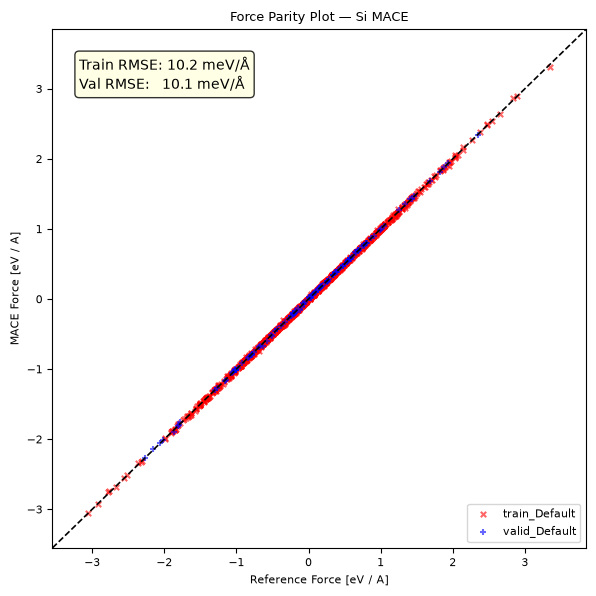

✅ Saved: ./results/force_parity.png


In [17]:
# ── Plot 2: Force Parity ───────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(tr_fr, tr_fp, c='red',  marker='x', s=15, alpha=0.6, label='train_Default')
ax.scatter(va_fr, va_fp, c='blue', marker='+', s=15, alpha=0.6, label='valid_Default')

lims = [min(tr_fr.min(), va_fr.min()) - 0.5,
        max(tr_fr.max(), va_fr.max()) + 0.5]
ax.plot(lims, lims, 'k--', linewidth=1.2)
ax.set_xlim(lims); ax.set_ylim(lims)

tr_frmse = np.sqrt(np.mean((tr_fr - tr_fp)**2)) * 1000
va_frmse = np.sqrt(np.mean((va_fr - va_fp)**2)) * 1000

ax.set_xlabel("Reference Force [eV / A]")
ax.set_ylabel("MACE Force [eV / A]")
ax.set_title("Force Parity Plot — Si MACE")
ax.legend()
ax.text(0.05, 0.95,
        f"Train RMSE: {tr_frmse:.1f} meV/Å\nVal RMSE:   {va_frmse:.1f} meV/Å",
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/force_parity.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {OUT_DIR}/force_parity.png")

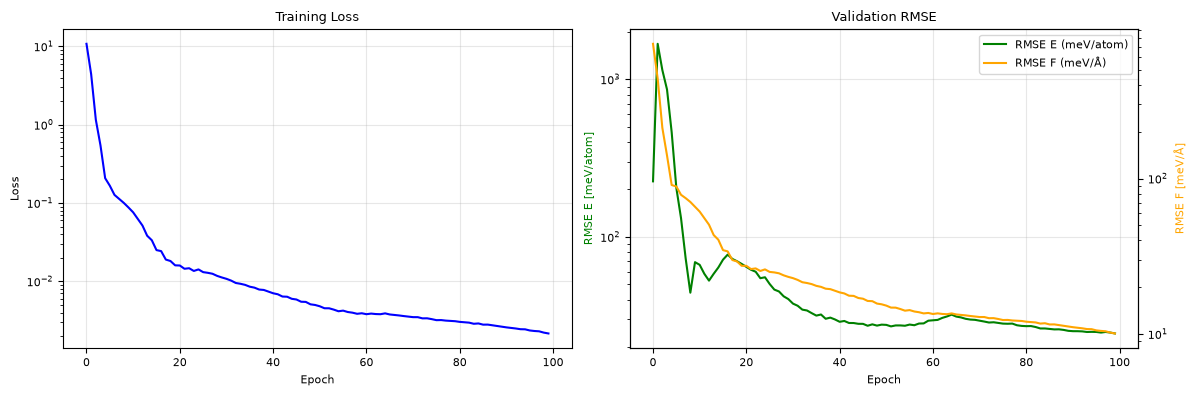

✅ Saved: ./results/training_curves.png


In [18]:
# ── Plot 3: Training Loss Curve (log file se) ──────────
import re

log_files = [f"./logs/{f}" for f in os.listdir("./logs")]
epochs, losses, e_rmse, f_rmse = [], [], [], []

for log_file in log_files:
    with open(log_file, 'r') as f:
        for line in f:
            m = re.search(
                r'Epoch (\d+):.*loss=([\d.]+).*RMSE_E_per_atom=\s*([\d.]+).*RMSE_F=\s*([\d.]+)',
                line)
            if m:
                epochs.append(int(m.group(1)))
                losses.append(float(m.group(2)))
                e_rmse.append(float(m.group(3)))
                f_rmse.append(float(m.group(4)))

# Sort by epoch
idx = np.argsort(epochs)
epochs  = np.array(epochs)[idx]
losses  = np.array(losses)[idx]
e_rmse  = np.array(e_rmse)[idx]
f_rmse  = np.array(f_rmse)[idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.semilogy(epochs, losses, 'b-', linewidth=1.5)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Training Loss"); ax1.grid(True, alpha=0.3)

# RMSE
ax2.semilogy(epochs, e_rmse, 'g-', label='RMSE E (meV/atom)', linewidth=1.5)
ax2_r = ax2.twinx()
ax2_r.semilogy(epochs, f_rmse, color='orange', label='RMSE F (meV/Å)', linewidth=1.5)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("RMSE E [meV/atom]", color='green')
ax2_r.set_ylabel("RMSE F [meV/Å]", color='orange')
ax2.set_title("Validation RMSE")
ax2.grid(True, alpha=0.3)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {OUT_DIR}/training_curves.png")

In [10]:
# Cell 1: Plots dhundo
import glob
import os

# MACE results folder check karo
result_paths = glob.glob("MACE_models/*/results/*.png")

print("Found plots:")
for p in sorted(result_paths):
    print(f"  {p}")

Found plots:


In [12]:
import os

print("=== ALL PNG FILES ===")
for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".png"):
            print(os.path.join(root, f))

print("\n=== ALL FOLDERS ===")
for root, dirs, files in os.walk("."):
    for d in dirs:
        print(os.path.join(root, d))

=== ALL PNG FILES ===

=== ALL FOLDERS ===
./results
./checkpoints
./logs


In [13]:
# Koi bhi MACE related file dhundo
print("=== MACE OUTPUT FILES ===")
for root, dirs, files in os.walk("."):
    for f in files:
        if any(ext in f for ext in ['.png', '.model', '.txt', '.log', '.pt']):
            print(os.path.join(root, f))

=== MACE OUTPUT FILES ===
./mace_Si.model
./mace_Si_compiled.model
./results/mace_Si_run-123_train.txt
./checkpoints/mace_Si_run-123_epoch-99.pt
./checkpoints/mace_Si_run-123.model
./logs/mace_Si_run-123_debug.log
./logs/mace_Si_run-123.log


In [14]:
import os

print(f"Current directory: {os.getcwd()}")
print("\nFiles here:")
for f in os.listdir("."):
    print(f"  {f}")

Current directory: /home/irslanullahashraf/si

Files here:
  mace_Si.model
  results
  checkpoints
  val.xyz
  test.xyz:Zone.Identifier
  mace_Si_compiled.model
  logs
  train.xyz:Zone.Identifier
  mace-train.ipynb
  val.xyz:Zone.Identifier
  test.xyz
  train.xyz


In [ ]:
# Cell 2: Jo bhi plots hain sab dekho
import glob
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Saari PNG files dhundo
result_files = glob.glob(f"MACE_models/{model_name}/results/*.png")
print(f"Total plots found: {len(result_files)}")

for img_path in sorted(result_files):
    print(f"\n📊 {os.path.basename(img_path)}")
    display(Image(img_path))

Total plots found: 0


In [9]:
# Cell 3: Custom parity plot — Predicted vs Actual Energy
from ase.io import read
from mace.calculators import MACECalculator
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "/home/irslanullahashraf/si"
model_name = "mace_Si"

# Model load karo
calc = MACECalculator(
    model_paths=f"MACE_models/{model_name}/{model_name}_run-123_stagetwo.model",
    device='cpu'
)

# Validation data load karo
val_configs = read(f"{DATA_DIR}/val.xyz", index=":")

e_ref, e_pred = [], []

for atoms in val_configs:
    # Reference energy (DFT)
    e_ref.append(atoms.info['REF_energy'] / len(atoms))
    
    # MACE predicted energy
    atoms.calc = calc
    e_pred.append(atoms.get_potential_energy() / len(atoms))

# Plot banao
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(e_ref, e_pred, alpha=0.6, s=30, color='steelblue')

# Perfect line
lims = [min(e_ref + e_pred), max(e_ref + e_pred)]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')

ax.set_xlabel("DFT Energy (eV/atom)")
ax.set_ylabel("MACE Predicted (eV/atom)")
ax.set_title("Energy Parity Plot — Si MACE Model")
ax.legend()

rmse = np.sqrt(np.mean((np.array(e_ref) - np.array(e_pred))**2)) * 1000
ax.text(0.05, 0.95, f"RMSE = {rmse:.2f} meV/atom",
        transform=ax.transAxes, fontsize=12,
        verticalalignment='top', color='red')

# Save karo
os.makedirs("my_results", exist_ok=True)
plt.savefig("my_results/energy_parity.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: my_results/energy_parity.png")

/home/irslanullahashraf/mace-env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


ValueError: Couldn't find MACE model files: MACE_models/mace_Si/mace_Si_run-123_stagetwo.model